In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm

In [2]:
# Paramètres et variables globales
mu = 100
laplace_scale = 1 / np.log(3)
gauss_scale = np.sqrt(2) / np.log(3)

x = np.linspace(95, 105, 1001)

# Densités Laplace
y1 = laplace.pdf(x, loc=mu  , scale=laplace_scale)
y2 = laplace.pdf(x, loc=mu+1, scale=laplace_scale)
y3 = laplace.pdf(x, loc=mu-1, scale=laplace_scale)
perte_conf_y2 = np.abs(np.log( y2 / y1 ))
perte_conf_y3 = np.abs(np.log( y3 / y1 ))
perte_conf_y = np.maximum(perte_conf_y2, perte_conf_y3)
cy1 = laplace.cdf(x, loc=mu  , scale=laplace_scale)

# Densités Gauss
z1 = norm.pdf(x, loc=mu  , scale=gauss_scale)
z2 = norm.pdf(x, loc=mu+1, scale=gauss_scale)
z3 = norm.pdf(x, loc=mu-1, scale=gauss_scale)
perte_conf_z2 = np.abs(np.log( z2 / z1 ))
perte_conf_z3 = np.abs(np.log( z3 / z1 ))
perte_conf_z = np.maximum(perte_conf_z2, perte_conf_z3)
cz1 = norm.cdf(x, loc=mu  , scale=gauss_scale)

# Fonction de densité

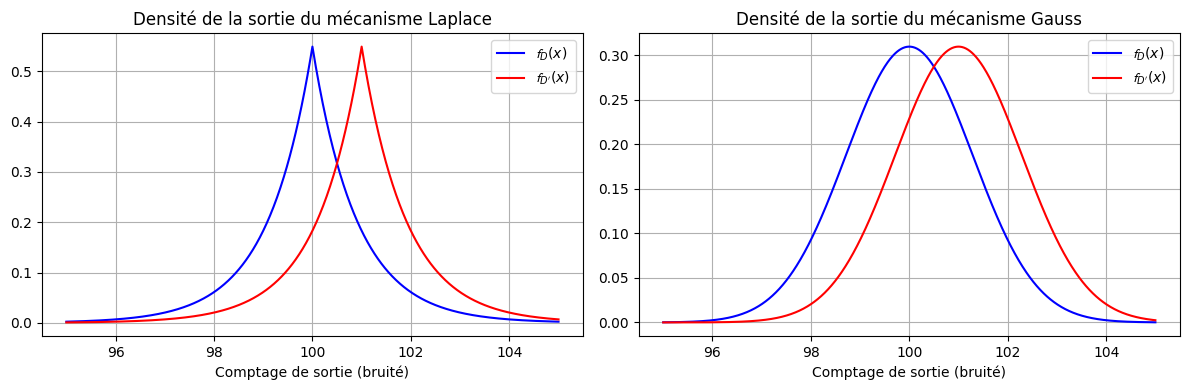

In [3]:
# Densités Laplace et Gauss
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(x, y1, label=r"$\mathcal{f}_D(x)$", color='blue')
axs[0].plot(x, y2, label=r"$\mathcal{f}_{D'}(x)$", color='red')
axs[0].set_xlabel("Comptage de sortie (bruité)")
axs[0].legend()
axs[0].grid(True)
axs[0].set_title("Densité de la sortie du mécanisme Laplace")

axs[1].plot(x, z1, label=r"$\mathcal{f}_D(x)$", color='blue')
axs[1].plot(x, z2, label=r"$\mathcal{f}_{D'}(x)$", color='red')
axs[1].set_xlabel("Comptage de sortie (bruité)")
axs[1].legend()
axs[1].grid(True)
axs[1].set_title("Densité de la sortie du mécanisme Gauss")

plt.tight_layout()
plt.show()

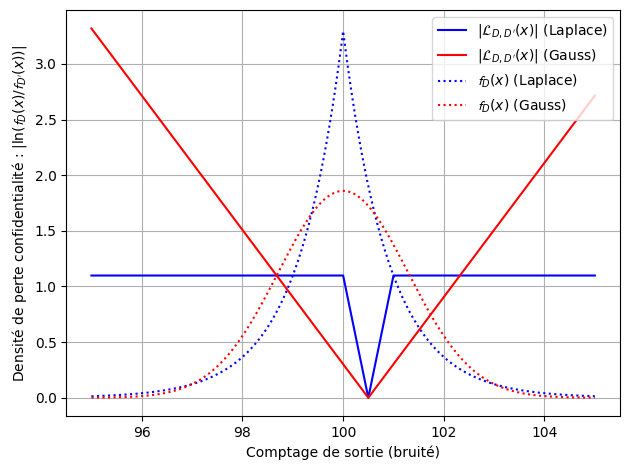

In [4]:
# Perte de confidentialité D,D+1 (Laplace et Gauss)
plt.plot(x, perte_conf_y2, label=r"$|\mathcal{L}_{D,D'}(x)|$ (Laplace)", color='blue')
plt.plot(x, perte_conf_z2, label=r"$|\mathcal{L}_{D,D'}(x)|$ (Gauss)", color='red')

plt.plot(x, 6*y1, label=r"$\mathcal{f}_D(x)$ (Laplace)", color='blue', linestyle="dotted")
plt.plot(x, 6*z1, label=r"$\mathcal{f}_D(x)$ (Gauss)", color='red', linestyle="dotted")

plt.xlabel("Comptage de sortie (bruité)")
plt.ylabel(r"Densité de perte confidentialité : $|\ln(\mathcal{f}_D(x)/\mathcal{f}_{D'}(x))|$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

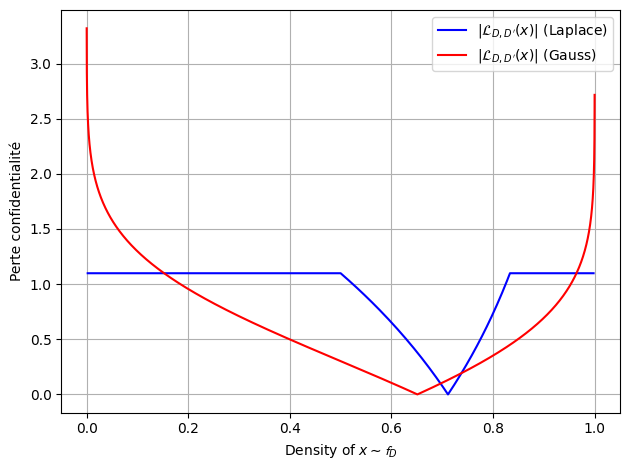

In [5]:
# Perte de confidentialité D,D+1 (Laplace et Gauss)
plt.plot(cy1, perte_conf_y2, label=r"$|\mathcal{L}_{D,D'}(x)|$ (Laplace)", color='blue')
plt.plot(cz1, perte_conf_z2, label=r"$|\mathcal{L}_{D,D'}(x)|$ (Gauss)", color='red')

plt.xlabel(r"Density of $x \sim \mathcal{f}_D$")
plt.ylabel(r"Perte confidentialité")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

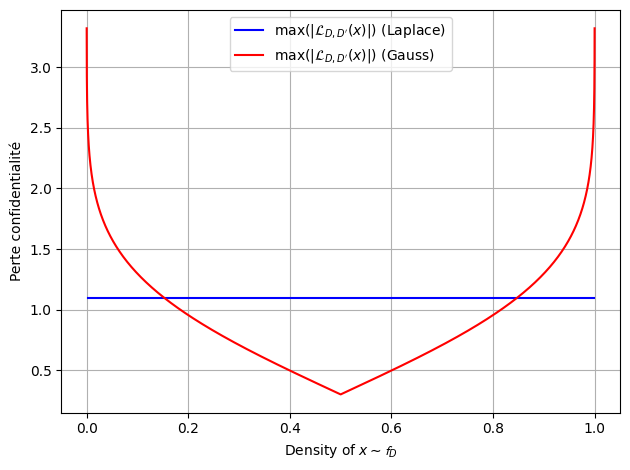

In [42]:
# Perte de confidentialité D,D' (Laplace et Gauss)
plt.plot(cy1, perte_conf_y, label=r"$\max(|\mathcal{L}_{D,D'}(x)|)$ (Laplace)", color='blue')
plt.plot(cz1, perte_conf_z, label=r"$\max(|\mathcal{L}_{D,D'}(x)|)$ (Gauss)", color='red')

plt.xlabel(r"Density of $x \sim \mathcal{f}_D$")
plt.ylabel(r"Perte confidentialité")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

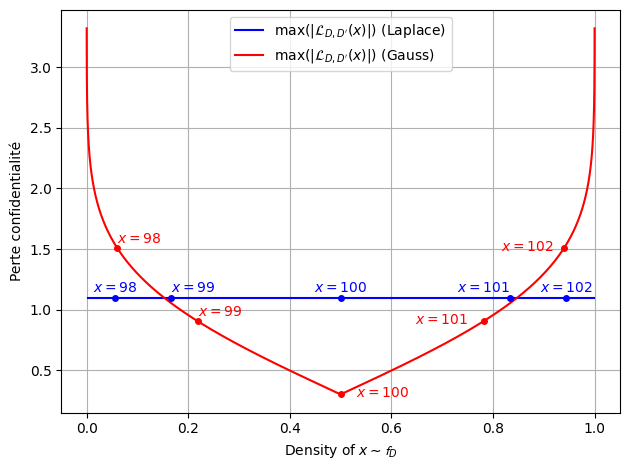

In [ ]:
# Perte de confidentialité D,D' annotée (Laplace et Gauss)
plt.plot(cy1, perte_conf_y, label=r"$\max(|\mathcal{L}_{D,D'}(x)|)$ (Laplace)", color='blue')
plt.plot(cz1, perte_conf_z, label=r"$\max(|\mathcal{L}_{D,D'}(x)|)$ (Gauss)", color='red')

def add_point(x_serie, y_serie, x_id, color, dx=0, dy=0, va='bottom', ha='left'):
    xp = x_serie[x_id]
    yp = y_serie[x_id]
    plt.plot(xp, yp, 'o', color=color, markersize=4)
    plt.text(xp+dx, yp+dy, r"$x=$"+f"{x[x_id]:.0f}", color=color, va=va, ha=ha)
def point_z(x_id, dx=0, dy=0.01, va='bottom', ha='left'):
    add_point(cz1, perte_conf_z, x_id, color="red", dx=dx, dy=dy, va=va, ha=ha)
def point_y(x_id, dx=0, dy=0.02, va='bottom', ha='center'):
    add_point(cy1, perte_conf_y, x_id, color="blue", dx=dx, dy=dy, va=va, ha=ha)

point_z(300, dy=0.02)
point_z(400, dy=0.02)
point_z(500, dx=0.03, va="center")
point_z(600, dx=-0.03, ha="right", va="center")
point_z(700, dx=-0.02, ha="right", va="center")

point_y(300)
point_y(400, ha="left")
point_y(500)
point_y(600, ha="right")
point_y(700)

plt.xlabel(r"Density of $x \sim \mathcal{f}_D$")
plt.ylabel(r"Perte confidentialité")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()